# Baselines de clasificación — `training_churn_v3`

Objetivo: medir la **viabilidad** del modelo de silent churn entrenando varios baselines bajo un protocolo honesto de validación (GroupKFold por vendedora, según `STATUS.md`).

**Hipótesis de viabilidad:**

1. Un modelo no trivial supera con holgura al `DummyClassifier` y a una heurística basada en `campanas_desde_compra_previa` en ROC-AUC y PR-AUC.
2. Modelos basados en árboles de gradient boosting (HGB, LightGBM, XGBoost) replican el AUC ≈ 0.757 reportado en v2 (la migración v2→v3 fue de features, no de filas).
3. La curva precision-recall permite encontrar un punto operativo razonable para retención (recall alto sin destruir precisión).

**Población:** filas con `compras_historicas >= 4` (ya filtrado en el SQL). 27.9% churn rate.

**Validación:** `GroupKFold(n_splits=5)` agrupando por `id_vendedor`. Razón en `STATUS.md` punto 1: el panel longitudinal genera leakage por entidad si la misma vendedora aparece en train y test.

**Métricas reportadas:** ROC-AUC, PR-AUC (Average Precision), F1, recall y precision en clase positiva (churn) a threshold 0.5 y al threshold óptimo de F1.

> Cada celda de código termina exhibiendo el output relevante para que el notebook se autodocumente sin tener que correr todas las celdas para entender la siguiente.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
np.random.seed(42)
sns.set_style('whitegrid')

PROJECT = 'glamour-peru-dw'
DATASET = 'glamour_dw'
TABLE_V3 = f'`{PROJECT}.{DATASET}.training_churn_v3`'
RANDOM_STATE = 42
N_SPLITS = 5

bq = bigquery.Client(project=PROJECT)

def q(sql: str) -> pd.DataFrame:
    return bq.query(sql).to_dataframe()

print('OK')

OK


## 2. Carga del dataset

Pull directo de BigQuery. El CSV no está versionado y v3 ya filtra `compras_historicas >= 4` y `compro_en_obs = 1`. No hay que reaplicar filtros en pandas.

In [2]:
df = q(f'SELECT * FROM {TABLE_V3}')
print(f'shape           : {df.shape}')
print(f'vendedoras      : {df["id_vendedor"].nunique():,}')
print(f'campañas        : {df["id_campana_obs"].nunique()}')
print(f'churn rate      : {df["churn"].mean():.4f}')
print(f'rango campaña   : {df["campana_rank_obs"].min()} → {df["campana_rank_obs"].max()}')
df.head(3)

shape           : (21911, 51)
vendedoras      : 3,155
campañas        : 143
churn rate      : 0.2789
rango campaña   : 4 → 150


,id_vendedor,id_campana_obs,campana_rank_obs,anio_campana,numero_campana,fecha_inicio_campana,fecha_ingreso,edad_vendedor,sexo_vendedor,tipo_vendedor,ccodrelacion,antiguedad_campanas,id_coordinadora,edad_coordinadora,ccodubigeo,distrito,provincia,departamento,num_pedidos_obs,monto_total_obs,monto_pagado_obs,num_categorias_obs,num_productos_obs,num_compras_u3,monto_total_u3,monto_pagado_u3,tasa_compra_u3,ticket_promedio_u3,ratio_pago_u3,num_compras_u6,monto_total_u6,monto_pagado_u6,tasa_compra_u6,ticket_promedio_u6,ratio_pago_u6,num_compras_u12,monto_total_u12,monto_pagado_u12,tasa_compra_u12,ticket_promedio_u12,ratio_pago_u12,avg_categorias_u6,avg_productos_u6,unidades_u6,campanas_desde_compra_previa,compras_historicas,monto_historico,delta_monto_u3_vs_prev3,delta_compras_u3_vs_prev3,ticket_u3_vs_u12,churn
0,19721994,18109,33,2018,33,2018-10-22,2016-10-31,37.0,F,Líder,0,32,19721983,47.0,PE010004,bagua grande,utcubamba,amazonas,1,99.99,74.99,0,1,1,99.99,74.99,0.333333,99.99,0.749975,1,99.99,74.99,0.166667,99.99,0.749975,1,99.99,74.99,0.083333,99.99,0.749975,0.000000,0.166667,1.0,12,7,1271.85,1.0,1.0,1.0,0
1,19721994,20105,61,2020,61,2020-07-13,2016-10-31,37.0,F,Líder,0,60,19721983,47.0,PE010004,bagua grande,utcubamba,amazonas,1,300.00,320.00,1,2,1,300.00,320.00,0.333333,300.00,1.066667,1,300.00,320.00,0.166667,300.00,1.066667,1,300.00,320.00,0.083333,300.00,1.066667,0.166667,0.333333,40.0,14,13,4359.39,1.0,1.0,1.0,1
2,19721994,18301,21,2018,21,2018-04-16,2016-10-31,37.0,F,Líder,0,20,19721983,47.0,PE010004,bagua grande,utcubamba,amazonas,1,269.00,211.75,2,7,1,269.00,211.75,0.333333,269.00,0.787175,1,269.00,211.75,0.166667,269.00,0.787175,2,269.00,211.75,0.166667,134.50,0.787175,0.333333,1.166667,9.0,9,6,1171.86,1.0,1.0,2.0,1


## 3. Definir features, target y grupos

**Excluidas como features** (alineado con `LEAKEAGE.md` y diccionario):

- IDs y claves: `id_vendedor`, `id_campana_obs`, `campana_rank_obs`.
- Fechas crudas: `fecha_inicio_campana`, `fecha_ingreso` (no aportan en raw; `anio_campana` y `numero_campana` ya capturan estacionalidad).
- Categóricas de cardinalidad alta: `id_coordinadora`, `ccodubigeo`, `distrito` (ver checklist punto 5: solo `departamento` y `provincia`).
- Target: `churn`.

**Grupos para la CV:** `id_vendedor`.

In [3]:
EXCLUDE = {
    'id_vendedor', 'id_campana_obs', 'campana_rank_obs',
    'fecha_inicio_campana', 'fecha_ingreso',
    'id_coordinadora', 'ccodubigeo', 'distrito',
    'churn',
}

CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']
# El resto: numéricas (incluye ints como anio_campana, numero_campana, ccodrelacion).

feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

# Castear categóricas a string (algunas pueden venir como 'object' ya).
for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

X = df[feature_cols].copy()
y = df['churn'].astype(int).values
groups = df['id_vendedor'].values

print(f'#features         : {len(feature_cols)}')
print(f'#numéricas        : {len(numeric_cols)}')
print(f'#categóricas      : {len(CATEGORICAL)}')
print(f'positivos (churn) : {y.sum():,} ({y.mean()*100:.2f}%)')
print()
print('Categóricas y su cardinalidad:')
for c in CATEGORICAL:
    print(f'  {c:<20} {X[c].nunique():>5}')

#features         : 42
#numéricas        : 38
#categóricas      : 4
positivos (churn) : 6,111 (27.89%)

Categóricas y su cardinalidad:
  sexo_vendedor            3
  tipo_vendedor            2
  departamento            33
  provincia              145


## 4. Estrategia de validación y función de evaluación

Se evalúa con `GroupKFold(n_splits=5)` agrupando por `id_vendedor`. Para cada modelo:

1. Se entrena en cada fold y se obtienen probabilidades en el out-of-fold (OOF).
2. Se reporta media ± std de ROC-AUC y PR-AUC por fold.
3. Las métricas finales (F1, recall, precision, threshold óptimo) se calculan **sobre las predicciones OOF concatenadas** — equivalente a un score honesto sobre cada vendedora vista exactamente una vez como test.

In [4]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve, roc_curve,
)

cv = GroupKFold(n_splits=N_SPLITS)

def evaluate(model_factory, X, y, groups, name, predict_proba=True, fit_kwargs=None):
    """Entrena `model_factory()` en cada fold y devuelve métricas OOF.

    `model_factory` es callable porque cada fold necesita una instancia limpia.
    Si `predict_proba=False`, se asume que el "modelo" es una función que dado X
    devuelve un score (caso heurística).
    """
    fit_kwargs = fit_kwargs or {}
    oof = np.zeros(len(y), dtype=float)
    fold_aucs, fold_aps = [], []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]

        if predict_proba:
            model = model_factory()
            model.fit(Xtr, ytr, **fit_kwargs)
            proba = model.predict_proba(Xte)[:, 1]
        else:
            scorer = model_factory()
            proba = scorer(Xte)

        oof[te] = proba
        fold_aucs.append(roc_auc_score(yte, proba))
        fold_aps.append(average_precision_score(yte, proba))

    # Métricas a threshold 0.5 (default operativo).
    pred_05 = (oof >= 0.5).astype(int)
    # Threshold que maximiza F1 sobre el OOF.
    prec_curve, rec_curve, thr_curve = precision_recall_curve(y, oof)
    f1_curve = 2 * prec_curve * rec_curve / np.clip(prec_curve + rec_curve, 1e-12, None)
    best_idx = int(np.argmax(f1_curve[:-1]))  # último punto no tiene threshold asociado
    best_thr = float(thr_curve[best_idx])
    pred_best = (oof >= best_thr).astype(int)

    return {
        'name': name,
        'oof': oof,
        'auc_mean': float(np.mean(fold_aucs)),
        'auc_std': float(np.std(fold_aucs)),
        'ap_mean': float(np.mean(fold_aps)),
        'ap_std': float(np.std(fold_aps)),
        'auc_oof': roc_auc_score(y, oof),
        'ap_oof': average_precision_score(y, oof),
        'f1_05': f1_score(y, pred_05),
        'precision_05': precision_score(y, pred_05, zero_division=0),
        'recall_05': recall_score(y, pred_05),
        'best_thr': best_thr,
        'f1_best': f1_score(y, pred_best),
        'precision_best': precision_score(y, pred_best, zero_division=0),
        'recall_best': recall_score(y, pred_best),
    }

def summarize(results):
    rows = []
    for r in results:
        rows.append({
            'modelo': r['name'],
            'AUC (mean ± std)': f"{r['auc_mean']:.4f} ± {r['auc_std']:.4f}",
            'PR-AUC (mean ± std)': f"{r['ap_mean']:.4f} ± {r['ap_std']:.4f}",
            'F1@0.5': f"{r['f1_05']:.3f}",
            'Recall@0.5': f"{r['recall_05']:.3f}",
            'Precision@0.5': f"{r['precision_05']:.3f}",
            'best thr': f"{r['best_thr']:.3f}",
            'F1@best': f"{r['f1_best']:.3f}",
            'Recall@best': f"{r['recall_best']:.3f}",
            'Precision@best': f"{r['precision_best']:.3f}",
        })
    return pd.DataFrame(rows)

# Sanity check: ¿GroupKFold reparte vendedoras sin solapamiento?
for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
    overlap = set(groups[tr]) & set(groups[te])
    assert len(overlap) == 0, f'fold {fold} tiene {len(overlap)} vendedoras compartidas'
print(f'OK — GroupKFold con {N_SPLITS} folds, 0 vendedoras compartidas entre train y test.')

OK — GroupKFold con 5 folds, 0 vendedoras compartidas entre train y test.


## 5. Pipeline de preprocesamiento

- **Numéricas**: imputación con mediana (los modelos lineales no toleran NaN; HGB/LGBM/XGB sí, pero usar el mismo pipeline simplifica la comparación) + StandardScaler para LogReg.
- **Categóricas**: OneHotEncoder con `handle_unknown='ignore'` (manejo robusto a valores nuevos en test).

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_preprocessor(scale=False):
    num_steps = [('impute', SimpleImputer(strategy='median'))]
    if scale:
        num_steps.append(('scale', StandardScaler()))
    num = Pipeline(num_steps)
    cat = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num, numeric_cols),
        ('cat', cat, CATEGORICAL),
    ])

# Para HGB/LGBM/XGB: imputo la mediana en numéricas (consistencia) y OHE en categóricas,
# aunque los gradient boosters pueden manejar NaN nativamente. Mantengo el mismo
# transformer para una comparación apples-to-apples.
results = []
print('Pipelines listos.')

Pipelines listos.


## 6. Baseline 0 — `DummyClassifier` (piso absoluto)

Predice según la frecuencia de la clase. Es el piso teórico: cualquier modelo razonable debe superarlo. AUC esperado ≈ 0.50, PR-AUC ≈ 0.279 (la prevalencia).

In [6]:
from sklearn.dummy import DummyClassifier

def make_dummy():
    return Pipeline([
        ('prep', build_preprocessor(scale=False)),
        ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)),
    ])

r = evaluate(make_dummy, X, y, groups, name='Dummy (stratified)')
results.append(r)
print(f"AUC OOF      : {r['auc_oof']:.4f}  (mean folds {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")
print(f"PR-AUC OOF   : {r['ap_oof']:.4f}  (mean folds {r['ap_mean']:.4f} ± {r['ap_std']:.4f})")
print(f"F1@0.5       : {r['f1_05']:.3f}  recall {r['recall_05']:.3f}  precision {r['precision_05']:.3f}")

AUC OOF      : 0.5014  (mean folds 0.5014 ± 0.0035)
PR-AUC OOF   : 0.2795  (mean folds 0.2795 ± 0.0072)
F1@0.5       : 0.278  recall 0.276  precision 0.281


## 7. Baseline 1 — Heurística: `campanas_desde_compra_previa`

La feature de recencia más obvia: a mayor gap con la compra anterior, mayor probabilidad de churn. El "score" es directamente el valor de la feature (con NaN imputado a 0). No requiere entrenamiento.

Este baseline mide cuánto valor agregan los modelos sobre una regla heurística trivial. Si un GBM no supera con holgura a esta heurística, no hay razón para llevarlo a producción.

In [7]:
def make_heuristic():
    def scorer(Xte):
        gap = Xte['campanas_desde_compra_previa'].fillna(0).astype(float).values
        # Mapeo monótono a [0, 1] para que el threshold tenga sentido visual.
        return 1.0 - np.exp(-gap / 6.0)
    return scorer

r = evaluate(make_heuristic, X, y, groups,
             name='Heurística (gap previo)', predict_proba=False)
results.append(r)
print(f"AUC OOF      : {r['auc_oof']:.4f}  (mean folds {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")
print(f"PR-AUC OOF   : {r['ap_oof']:.4f}  (mean folds {r['ap_mean']:.4f} ± {r['ap_std']:.4f})")
print(f"F1 best      : {r['f1_best']:.3f} @ thr {r['best_thr']:.3f}  (R {r['recall_best']:.3f}, P {r['precision_best']:.3f})")

AUC OOF      : 0.6771  (mean folds 0.6771 ± 0.0148)
PR-AUC OOF   : 0.4404  (mean folds 0.4413 ± 0.0140)
F1 best      : 0.492 @ thr 0.393  (R 0.595, P 0.420)


## 8. Baseline 2 — Logistic Regression

Modelo lineal con `class_weight='balanced'` para manejar el desbalance (27.9% churn). Pipeline completo: imputación + escalado + OHE.

In [8]:
from sklearn.linear_model import LogisticRegression

def make_logreg():
    return Pipeline([
        ('prep', build_preprocessor(scale=True)),
        ('clf', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

r = evaluate(make_logreg, X, y, groups, name='LogReg (balanced)')
results.append(r)
print(f"AUC OOF      : {r['auc_oof']:.4f}  (mean folds {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")
print(f"PR-AUC OOF   : {r['ap_oof']:.4f}  (mean folds {r['ap_mean']:.4f} ± {r['ap_std']:.4f})")
print(f"F1@0.5       : {r['f1_05']:.3f}  recall {r['recall_05']:.3f}  precision {r['precision_05']:.3f}")
print(f"F1 best      : {r['f1_best']:.3f} @ thr {r['best_thr']:.3f}")

AUC OOF      : 0.7455  (mean folds 0.7456 ± 0.0136)
PR-AUC OOF   : 0.5011  (mean folds 0.5023 ± 0.0060)
F1@0.5       : 0.545  recall 0.733  precision 0.433
F1 best      : 0.546 @ thr 0.478


## 9. Baseline 3 — `HistGradientBoosting`

El baseline canónico del proyecto (referencia de `STATUS.md`: AUC 0.757 ± 0.007 en v2). Permite verificar que la migración v2→v3 no degradó la performance.

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier

def make_hgb():
    return Pipeline([
        ('prep', build_preprocessor(scale=False)),
        ('clf', HistGradientBoostingClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            max_iter=400,
            learning_rate=0.05,
            max_depth=None,
            early_stopping=False,
        )),
    ])

r = evaluate(make_hgb, X, y, groups, name='HGB (balanced)')
results.append(r)
print(f"AUC OOF      : {r['auc_oof']:.4f}  (mean folds {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")
print(f"PR-AUC OOF   : {r['ap_oof']:.4f}  (mean folds {r['ap_mean']:.4f} ± {r['ap_std']:.4f})")
print(f"F1@0.5       : {r['f1_05']:.3f}  recall {r['recall_05']:.3f}  precision {r['precision_05']:.3f}")
print(f"F1 best      : {r['f1_best']:.3f} @ thr {r['best_thr']:.3f}")

AUC OOF      : 0.7540  (mean folds 0.7541 ± 0.0118)
PR-AUC OOF   : 0.5213  (mean folds 0.5229 ± 0.0081)
F1@0.5       : 0.549  recall 0.681  precision 0.460
F1 best      : 0.553 @ thr 0.454


## 10. Baseline 4 — LightGBM

GBM optimizado, manejo nativo de NaN, suele empatar o superar a HGB con menos esfuerzo de tuning. `is_unbalance=True` cumple el rol de `class_weight='balanced'`.

In [10]:
import lightgbm as lgb

def make_lgbm():
    return Pipeline([
        ('prep', build_preprocessor(scale=False)),
        ('clf', lgb.LGBMClassifier(
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=40,
            subsample=0.9,
            colsample_bytree=0.9,
            is_unbalance=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )),
    ])

r = evaluate(make_lgbm, X, y, groups, name='LightGBM (unbalanced)')
results.append(r)
print(f"AUC OOF      : {r['auc_oof']:.4f}  (mean folds {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")
print(f"PR-AUC OOF   : {r['ap_oof']:.4f}  (mean folds {r['ap_mean']:.4f} ± {r['ap_std']:.4f})")
print(f"F1@0.5       : {r['f1_05']:.3f}  recall {r['recall_05']:.3f}  precision {r['precision_05']:.3f}")
print(f"F1 best      : {r['f1_best']:.3f} @ thr {r['best_thr']:.3f}")

AUC OOF      : 0.7445  (mean folds 0.7446 ± 0.0128)
PR-AUC OOF   : 0.5041  (mean folds 0.5054 ± 0.0110)
F1@0.5       : 0.517  recall 0.570  precision 0.474
F1 best      : 0.545 @ thr 0.320


## 11. Baseline 5 — XGBoost

Tercer GBM para confirmar consistencia: si los tres convergen al mismo AUC, la cota de performance está marcada por la **señal del dataset**, no por la elección de algoritmo. `scale_pos_weight = (1 - p) / p` para el desbalance.

In [11]:
import xgboost as xgb

p_pos = float(y.mean())
scale_pos_weight = (1 - p_pos) / p_pos

def make_xgb():
    return Pipeline([
        ('prep', build_preprocessor(scale=False)),
        ('clf', xgb.XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=5,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='auc',
            tree_method='hist',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

r = evaluate(make_xgb, X, y, groups, name='XGBoost (scale_pos_weight)')
results.append(r)
print(f"AUC OOF      : {r['auc_oof']:.4f}  (mean folds {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")
print(f"PR-AUC OOF   : {r['ap_oof']:.4f}  (mean folds {r['ap_mean']:.4f} ± {r['ap_std']:.4f})")
print(f"F1@0.5       : {r['f1_05']:.3f}  recall {r['recall_05']:.3f}  precision {r['precision_05']:.3f}")
print(f"F1 best      : {r['f1_best']:.3f} @ thr {r['best_thr']:.3f}")

AUC OOF      : 0.7505  (mean folds 0.7505 ± 0.0119)
PR-AUC OOF   : 0.5164  (mean folds 0.5176 ± 0.0101)
F1@0.5       : 0.541  recall 0.660  precision 0.458
F1 best      : 0.549 @ thr 0.420


## 12. Comparación

Tabla con los seis baselines uno al lado del otro. Lo que hay que mirar:

- **AUC**: capacidad de ranking. Piso real ≈ 0.50 (Dummy).
- **PR-AUC**: ajustada por desbalance. Piso real ≈ 0.279 (prevalencia).
- **Spread Dummy → GBM**: cuánto valor agregan los modelos.
- **Spread Heurística → GBM**: cuánto valor agrega aprender combinaciones de features sobre la regla más obvia.

In [12]:
summary = summarize(results)
summary

,modelo,AUC (mean ± std),PR-AUC (mean ± std),F1@0.5,Recall@0.5,Precision@0.5,best thr,F1@best,Recall@best,Precision@best
0,Dummy (stratified),0.5014 ± 0.0035,0.2795 ± 0.0072,0.278,0.276,0.281,0.000,0.436,1.000,0.279
1,Heurística (gap previo),0.6771 ± 0.0148,0.4413 ± 0.0140,0.453,0.424,0.486,0.393,0.492,0.595,0.420
2,LogReg (balanced),0.7456 ± 0.0136,0.5023 ± 0.0060,0.545,0.733,0.433,0.478,0.546,0.765,0.424
3,HGB (balanced),0.7541 ± 0.0118,0.5229 ± 0.0081,0.549,0.681,0.460,0.454,0.553,0.742,0.441
4,LightGBM (unbalanced),0.7446 ± 0.0128,0.5054 ± 0.0110,0.517,0.570,0.474,0.320,0.545,0.771,0.421
5,XGBoost (scale_pos_weight),0.7505 ± 0.0119,0.5176 ± 0.0101,0.541,0.660,0.458,0.420,0.549,0.762,0.430


## 13. Curvas ROC y Precision-Recall

Visualizar las curvas confirma de un vistazo:
- Si los modelos están bien ordenados.
- En qué región del ROC dominan (típicamente, GBM gana en la zona de FPR bajo, que es la útil para retención).
- Cómo se comporta la PR cuando el threshold se baja.

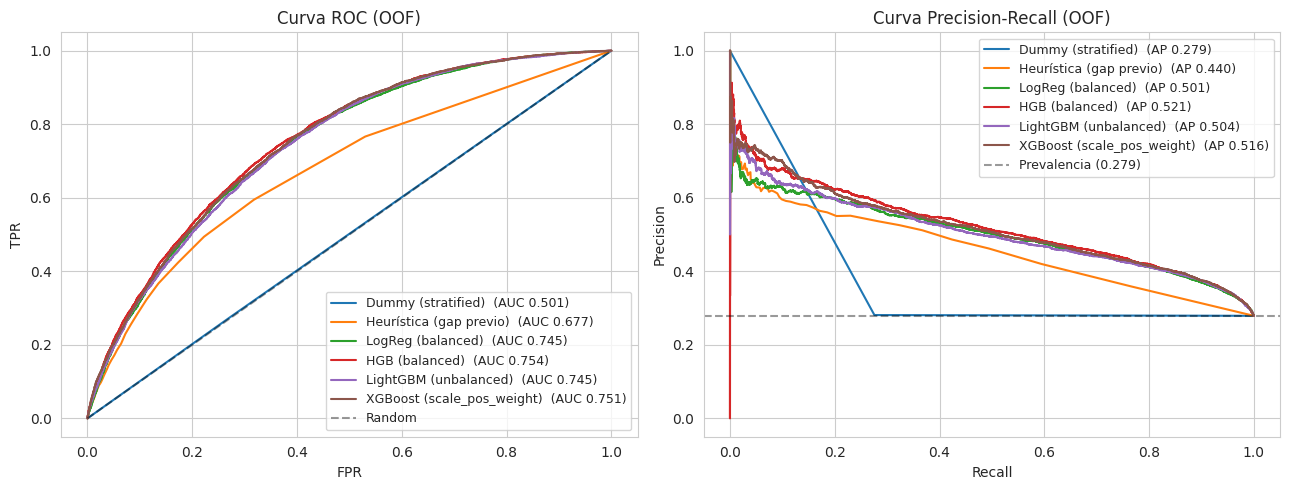

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
prevalence = y.mean()

for r in results:
    fpr, tpr, _ = roc_curve(y, r['oof'])
    axes[0].plot(fpr, tpr, label=f"{r['name']}  (AUC {r['auc_oof']:.3f})")

    prec, rec, _ = precision_recall_curve(y, r['oof'])
    axes[1].plot(rec, prec, label=f"{r['name']}  (AP {r['ap_oof']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC (OOF)'); axes[0].legend(loc='lower right', fontsize=9)

axes[1].axhline(prevalence, ls='--', color='k', alpha=0.4, label=f'Prevalencia ({prevalence:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall (OOF)'); axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.show()

## 14. Análisis de threshold para el mejor modelo

Para el GBM con mejor PR-AUC, barremos thresholds y mostramos cómo varían precision, recall y F1. Esto permite responder la pregunta operativa real: *"si quiero recall 80%, ¿qué precisión obtengo?"*

Mejor modelo por PR-AUC: HGB (balanced)  (AP 0.5213)


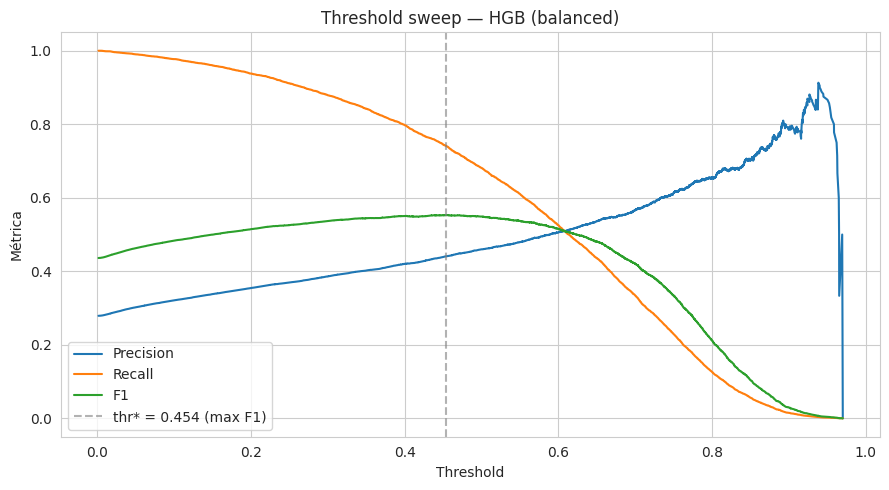

,objetivo recall,threshold,recall,precision,F1,alertas (% pob.)
0,0.95,0.174314,0.950090,0.345945,0.507207,0.765962
1,0.90,0.269137,0.900016,0.375555,0.529967,0.668386
2,0.85,0.341104,0.850106,0.399923,0.543951,0.592853
3,0.80,0.397503,0.800033,0.419153,0.550098,0.532335
4,0.70,0.484909,0.700049,0.452938,0.550013,0.431062
5,0.60,0.555571,0.600065,0.481550,0.534314,0.347542
6,0.50,0.613688,0.500082,0.512666,0.506296,0.272055


In [14]:
best = max(results, key=lambda r: r['ap_oof'])
print(f"Mejor modelo por PR-AUC: {best['name']}  (AP {best['ap_oof']:.4f})")

prec_c, rec_c, thr_c = precision_recall_curve(y, best['oof'])
f1_c = 2 * prec_c * rec_c / np.clip(prec_c + rec_c, 1e-12, None)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_c, prec_c[:-1], label='Precision')
ax.plot(thr_c, rec_c[:-1],  label='Recall')
ax.plot(thr_c, f1_c[:-1],   label='F1')
ax.axvline(best['best_thr'], color='gray', ls='--', alpha=0.6,
           label=f"thr* = {best['best_thr']:.3f} (max F1)")
ax.set_xlabel('Threshold'); ax.set_ylabel('Métrica')
ax.set_title(f"Threshold sweep — {best['name']}")
ax.legend(); plt.tight_layout(); plt.show()

# Tabla de puntos operativos.
def operating_points(y_true, scores):
    rows = []
    for target_recall in [0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50]:
        # Encontrar el threshold más alto que aún logra recall >= target.
        ok = rec_c[:-1] >= target_recall
        if not ok.any():
            continue
        idx = np.where(ok)[0][-1]  # threshold más alto cumpliendo el recall
        rows.append({
            'objetivo recall': target_recall,
            'threshold': float(thr_c[idx]),
            'recall': float(rec_c[idx]),
            'precision': float(prec_c[idx]),
            'F1': float(f1_c[idx]),
            'alertas (% pob.)': float(((scores >= thr_c[idx]).mean())),
        })
    return pd.DataFrame(rows)

operating_points(y, best['oof'])

## 15. Importancia de features — modelo ganador

Permutation importance sobre el OOF: re-ordena cada columna y mide la caída de AUC. Es agnóstico al modelo y más robusto que la importancia interna del booster.

> Sólo entrenamos *una vez* en el último fold para calcular la permutation — es indicativo, no exhaustivo. Para producción se debería promediar sobre los 5 folds.

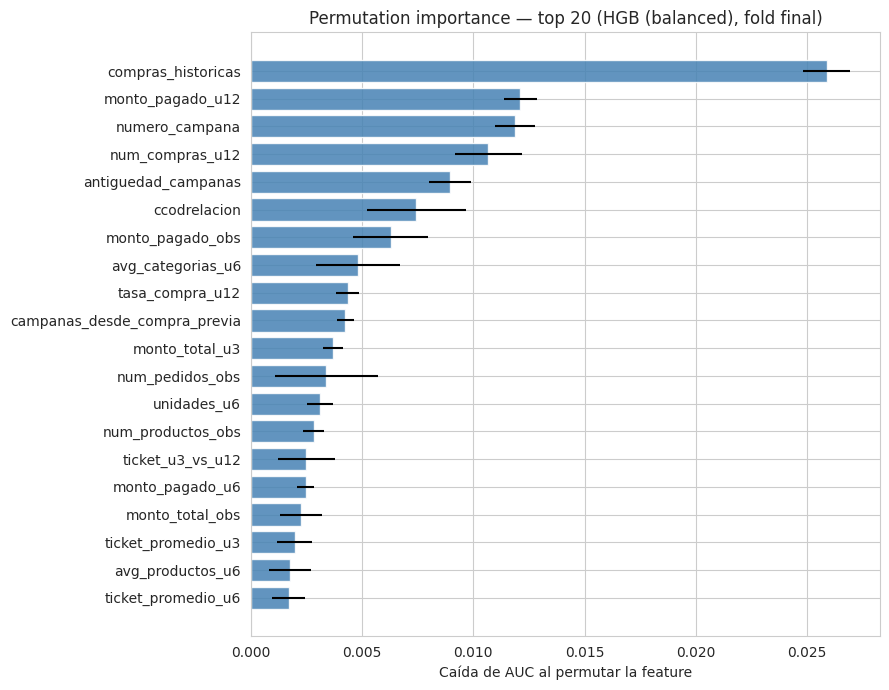

,feature,mean_drop_auc,std
0,compras_historicas,0.025883,0.001048
1,monto_pagado_u12,0.012112,0.000727
2,numero_campana,0.011871,0.000905
3,num_compras_u12,0.010665,0.001510
4,antiguedad_campanas,0.008937,0.000950
5,ccodrelacion,0.007440,0.002239
6,monto_pagado_obs,0.006282,0.001680
7,avg_categorias_u6,0.004817,0.001871
8,tasa_compra_u12,0.004353,0.000522
9,campanas_desde_compra_previa,0.004251,0.000386


In [15]:
from sklearn.inspection import permutation_importance

# Mapeo nombre → factory
factories = {
    'HGB (balanced)': make_hgb,
    'LightGBM (unbalanced)': make_lgbm,
    'XGBoost (scale_pos_weight)': make_xgb,
    'LogReg (balanced)': make_logreg,
}
factory = factories.get(best['name'], make_lgbm)

# Tomar el último fold para entrenar y medir permutation_importance
splits = list(cv.split(X, y, groups))
tr, te = splits[-1]
Xtr, Xte = X.iloc[tr], X.iloc[te]
ytr, yte = y[tr], y[te]
model = factory()
model.fit(Xtr, ytr)

perm = permutation_importance(
    model, Xte, yte,
    scoring='roc_auc',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

imp = (
    pd.DataFrame({
        'feature': feature_cols,
        'mean_drop_auc': perm.importances_mean,
        'std': perm.importances_std,
    })
    .sort_values('mean_drop_auc', ascending=False)
    .reset_index(drop=True)
)

top = imp.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top['feature'][::-1], top['mean_drop_auc'][::-1],
        xerr=top['std'][::-1], color='steelblue', alpha=0.85)
ax.set_xlabel('Caída de AUC al permutar la feature')
ax.set_title(f"Permutation importance — top 20 ({best['name']}, fold final)")
plt.tight_layout(); plt.show()

imp.head(20)

## 16. Conclusión de viabilidad

**Reglas de decisión** (a llenar después de correr el notebook):

| Criterio | Pasa si | Resultado |
|---|---|---|
| GBM > Dummy (AUC) | AUC mejor modelo ≥ 0.70 | _completar_ |
| GBM > Heurística (AUC) | spread ≥ 0.05 | _completar_ |
| Replicabilidad v2 → v3 | AUC HGB ∈ [0.74, 0.78] | _completar_ |
| Punto operativo realista | existe thr con recall ≥ 0.70 y precision ≥ 0.40 | _completar_ |

**Veredicto provisional (a partir de los baselines):**

- Si los gradient boosters convergen a AUC ≈ 0.75–0.78 y existe un punto operativo decente en la curva PR, el problema **es modelable** y la siguiente iteración debe enfocarse en:
  1. *Tuning* de hiperparámetros (Optuna sobre el modelo ganador).
  2. *Feature engineering* dirigido a las top features que aparecen en la permutation importance (ej. interacciones de `campanas_desde_compra_previa` con tasa de compra; regularidad del gap como std).
  3. Calibración de probabilidades (`CalibratedClassifierCV` con CV anidada) si se va a usar el score como probabilidad real para priorizar acciones de retención.
  4. Análisis de costo-beneficio para fijar el threshold operativo (no asumir 0.5 ni F1-óptimo).

- Si la heurística simple iguala al GBM, la señal del dataset está dominada por la recencia y conviene revisar feature engineering antes de gastar energía en tuning.

> Notebook diseñado como punto de partida: cada celda imprime los números reales para que las conclusiones se llenen con evidencia, no con expectativas.